# Startup Founder Burnout Analysis 2026
## Part 2: Predictive Modeling & Insights



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import joblib
import os
os.makedirs('models', exist_ok=True)

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [27]:
df = pd.read_csv('/content/startup_founder_burnout_2026.csv')
print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (50000, 29)


,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,...,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,...,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,...,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1


In [28]:
df['Work_Intensity'] = df['Weekly_Work_Hours'] / df['Sleep_Hours']
df['Total_Stress'] = (df['Investor_Pressure_Score'] +
                      df['Cofounder_Conflict_Score'] +
                      df['Decision_Fatigue_Score'] +
                      df['Stress_Score']) / 4

df['Experience_Level'] = pd.cut(df['Founder_Experience_Years'],
                                bins=[-1, 2, 5, 10, 20],
                                labels=['Novice', 'Intermediate', 'Experienced', 'Veteran'])

## *********** SELECT FEATURES *************

In [29]:
features = [
    'Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week',
    'Investor_Pressure_Score', 'Cofounder_Conflict_Score',
    'Decision_Fatigue_Score', 'Stress_Score',
    'Work_Intensity', 'Total_Stress',
    'Founder_Age', 'Founder_Experience_Years',
    'Team_Size', 'Startup_Age_Months',
    'Product_Market_Fit_Score', 'Runway_Months_Remaining'
]

X = df[features]
y = df['Founder_Burnout_Flag']

print("Features used:", X.columns.tolist())

Features used: ['Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week', 'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Decision_Fatigue_Score', 'Stress_Score', 'Work_Intensity', 'Total_Stress', 'Founder_Age', 'Founder_Experience_Years', 'Team_Size', 'Startup_Age_Months', 'Product_Market_Fit_Score', 'Runway_Months_Remaining']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 37500
Testing samples: 12500


In [31]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       random_state=42)



# *********** MODEL EVALUATION ****************



In [32]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

=== Model Performance ===
Accuracy: 0.9051
ROC-AUC Score: 0.9388

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95     11184
           1       0.54      0.75      0.63      1316

    accuracy                           0.91     12500
   macro avg       0.75      0.84      0.79     12500
weighted avg       0.92      0.91      0.91     12500





## Confusion Matrix



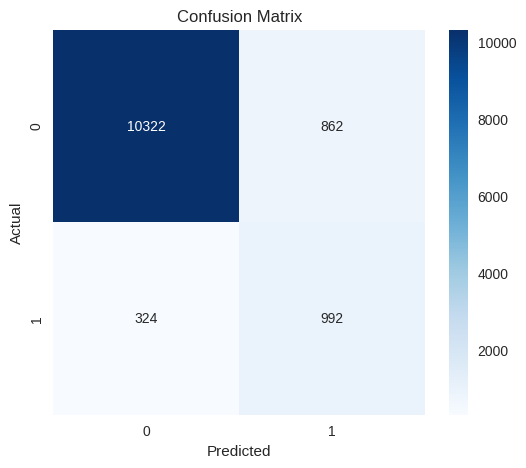

In [33]:
# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ********** FEATURE IMPORTANCE **************

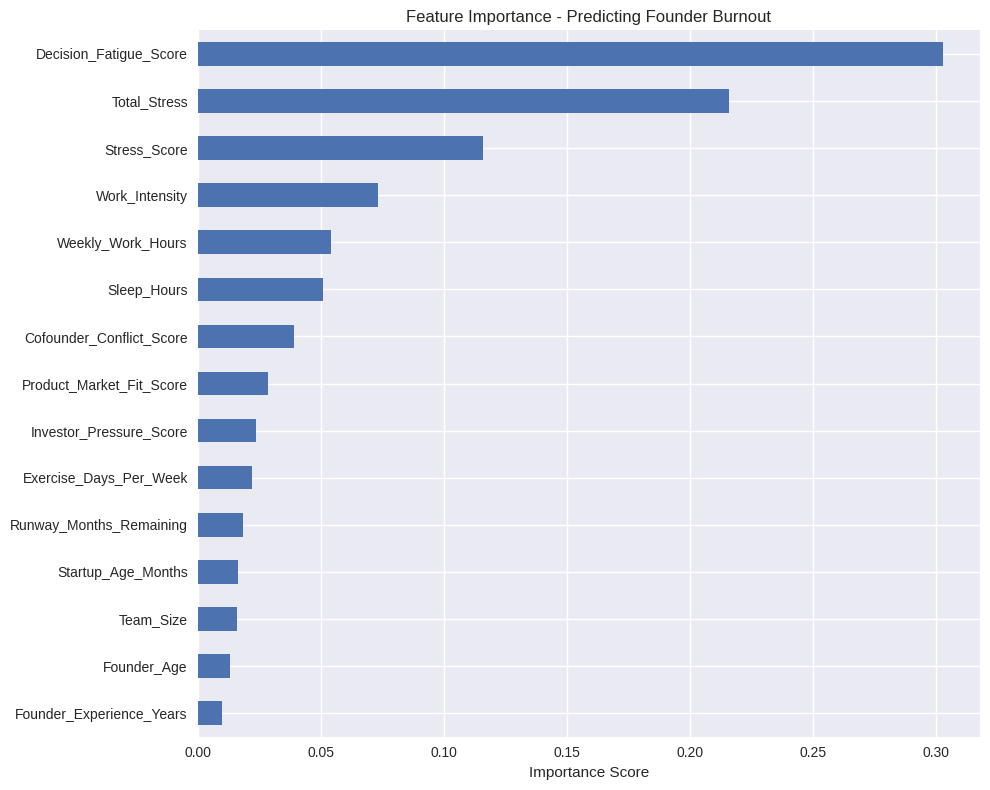


Top 10 Most Important Features:
Decision_Fatigue_Score      0.302536
Total_Stress                0.215758
Stress_Score                0.116007
Work_Intensity              0.073148
Weekly_Work_Hours           0.054298
Sleep_Hours                 0.050979
Cofounder_Conflict_Score    0.038954
Product_Market_Fit_Score    0.028660
Investor_Pressure_Score     0.023688
Exercise_Days_Per_Week      0.021971
dtype: float64


In [34]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title('Feature Importance - Predicting Founder Burnout')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importances.sort_values(ascending=False).head(10))

In [35]:
# Save the model
joblib.dump(model, 'burnout_predictor_model.pkl')
print("Model saved successfully!")

Model saved successfully!


# ************** EXAMPLE PREDICTION **********
## Test with a sample founder

In [36]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)
probability = model.predict_proba(sample)[0][1]

print(f"Predicted Burnout Flag: {prediction[0]}")
print(f"Probability of Burnout: {probability:.1%}")

Predicted Burnout Flag: 0
Probability of Burnout: 0.0%


In [39]:
import joblib

# Load the model
model = joblib.load('burnout_predictor_model.pkl')

print("✅ Model loaded successfully!")
print("Model type:", type(model))

✅ Model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
